In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad

In [11]:
def exacta(x):
    return 1 - np.e + np.exp(x) * (2 - x) - x


def fem(Nelem):
    h = 1.0 / Nelem
    puntos = np.linspace(0, 1, Nelem + 1)

    # Matriz de rigidez global
    M = np.zeros((Nelem + 1, Nelem + 1), float)

    M[0, 0] = 2 / h

    for j in range(1, Nelem + 1):
        M[j, j] = 2 / h
        M[j, j - 1] = -1 / h
        M[j - 1, j] = -1 / h

    # Integración del término fuente
    def integral_a(xa, xb):
        return quad(
            lambda x: x * np.exp(x) * (x - xa) / h,
            xa, xb
        )[0]

    def integral_b(xa, xb):
        return quad(
            lambda x: x * np.exp(x) * (xb - x) / h,
            xa, xb
        )[0]

    # Vector de carga
    carga = np.zeros(Nelem + 1, float)

    for j in range(1, Nelem + 1):
        carga[j - 1] += integral_b(puntos[j - 1], puntos[j])
        carga[j] += integral_a(puntos[j - 1], puntos[j])

    # Condiciones de frontera
    izquierda = 3 - np.e
    derecha = 0.0

    carga[1] -= izquierda * M[1, 0]
    carga[Nelem - 1] -= derecha * M[Nelem - 1, Nelem]

    carga[0] = izquierda
    carga[Nelem] = derecha

    M[0, 0] = 1
    M[0, 1] = 0
    M[1, 0] = 0

    M[Nelem, Nelem] = 1
    M[Nelem, Nelem - 1] = 0
    M[Nelem - 1, Nelem] = 0

    # Resolver el sistema
    resultado = np.linalg.solve(M, carga)

    return puntos, resultado



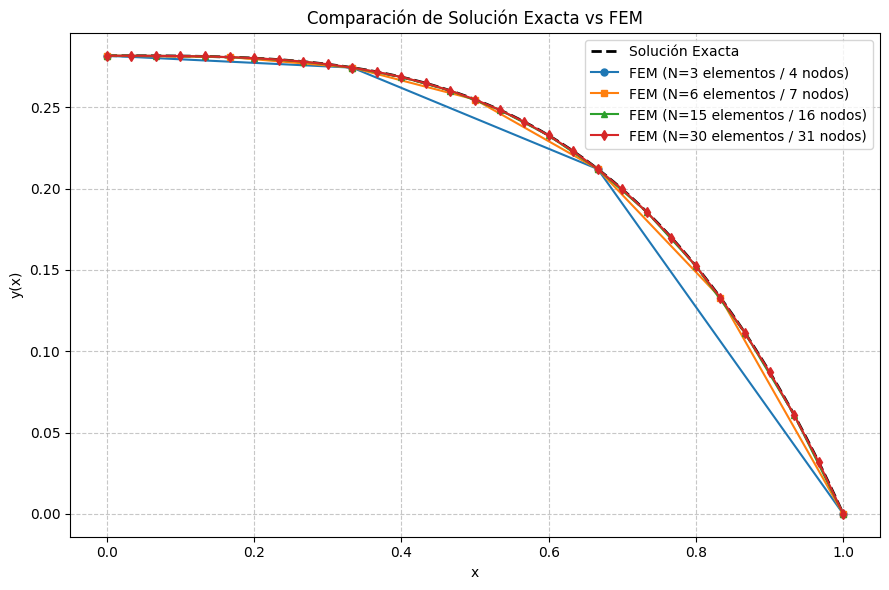

In [15]:

# Número de elementos que vamos a comparar
valores_N = [3, 6, 15, 30]

x_exacta = np.linspace(0, 1, 200)
y_exacta = exacta(x_exacta)

plt.figure(figsize=(9, 6))

# Solución exacta
plt.plot(
    x_exacta,
    y_exacta,
    'k--',
    label='Solución Exacta',
    linewidth=2
)

# Soluciones FEM
formatos = ['o-', 's-', '^-', 'd-']

for j in range(len(valores_N)):

    Nelem = valores_N[j]

    puntos, resultado = fem(Nelem)

    plt.plot(
        puntos,
        resultado,
        formatos[j],
        label=f'FEM (N={Nelem} elementos / {Nelem + 1} nodos)',
        markersize=5
    )


plt.title('Comparación de Solución Exacta vs FEM')
plt.xlabel('x')
plt.ylabel('y(x)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(loc='best')
plt.tight_layout()
plt.show()